# 02 - Market Microstructure EDA

In [1]:

from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
PROCESSED = ROOT / "data/processed/synthetic_h50"
print("Repository:", ROOT)
print("Processed data:", PROCESSED)


Repository: /home/shuaigou2025/projects/cost-aware-limit-order-book-forecasting
Processed data: /home/shuaigou2025/projects/cost-aware-limit-order-book-forecasting/data/processed/synthetic_h50


In [2]:
from lob_project.data.processed import load_processed

data = load_processed(PROCESSED)
source = np.load(PROCESSED / "source_features.npy", mmap_mode="r")
best_ask = source[:, 0]
ask_volume = source[:, 1]
best_bid = source[:, 2]
bid_volume = source[:, 3]
mid = (best_ask + best_bid) / 2
spread = best_ask - best_bid
imbalance = bid_volume / (bid_volume + ask_volume)
assert np.all(spread >= 0)


In [3]:
pd.DataFrame({
    "mid": mid,
    "spread": spread,
    "top_level_imbalance": imbalance,
}).describe(percentiles=[0.01, 0.1, 0.5, 0.9, 0.99])

,mid,spread,top_level_imbalance
count,8000.000000,8000.000000,8000.000000
mean,95.425545,0.011901,0.491990
std,2.165848,0.003924,0.122716
min,91.517769,0.009903,0.115311
1%,91.630139,0.009987,0.225724
10%,92.362946,0.009995,0.332860
50%,95.323410,0.010002,0.491439
90%,98.074304,0.019997,0.653631
99%,99.985359,0.020012,0.765023
max,100.301346,0.020035,0.877610


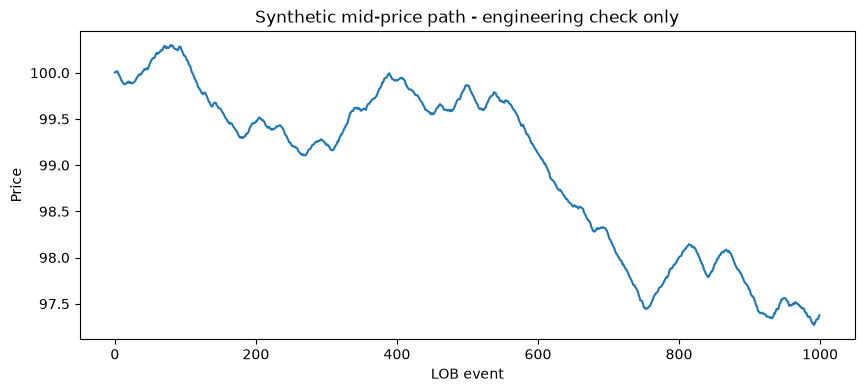

In [4]:
window = slice(0, 1000)
plt.figure(figsize=(10, 4))
plt.plot(mid[window])
plt.title("Synthetic mid-price path - engineering check only")
plt.xlabel("LOB event")
plt.ylabel("Price")
plt.show()

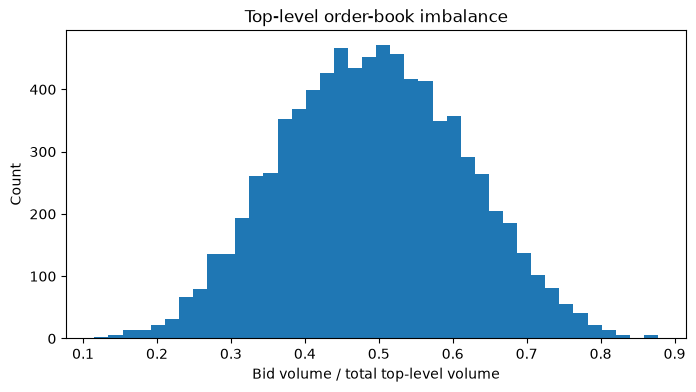

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(imbalance, bins=40)
plt.title("Top-level order-book imbalance")
plt.xlabel("Bid volume / total top-level volume")
plt.ylabel("Count")
plt.show()